# RAG Medical Q&A System


## PHASE 1: Data Pipeline

###  1 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
# Create our project folder structure on Drive
import os
BASE_DIR = '/content/drive/MyDrive/RAG'
dirs = [
    f'{BASE_DIR}/data/raw',
    f'{BASE_DIR}/data/processed',
    f'{BASE_DIR}/data/eval',
    f'{BASE_DIR}/index',
    f'{BASE_DIR}/results',
]
for d in dirs:
    os.makedirs(d, exist_ok=True)
    print(f'✅ {d}')

Mounted at /content/drive
✅ /content/drive/MyDrive/RAG/data/raw
✅ /content/drive/MyDrive/RAG/data/processed
✅ /content/drive/MyDrive/RAG/data/eval
✅ /content/drive/MyDrive/RAG/index
✅ /content/drive/MyDrive/RAG/results


###  2 — Install Dependencies

In [3]:
!pip install -q kaggle ijson pandas pyarrow tqdm
print("✅ All packages installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.9/149.9 kB 3.5 MB/s eta 0:00:00
✅ All packages installed


###  3 — Configure Kaggle from Colab Secrets

In [4]:
import os
from google.colab import userdata
# Load from Colab Secrets (🔑 icon in left sidebar)
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
# Quick verification
!kaggle datasets list --search "cornell arxiv" 2>&1 | head -5
print("\n✅ Kaggle credentials configured successfully")

ref                                                  title                                          size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------  ---------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
Cornell-University/arxiv                             arXiv Dataset                            1826116405  2026-09-05 23:51:21.573000         131380       1673  0.875            
awester/arxiv-embeddings                             arXiv embeddings                         5798025673  2026-05-10 12:34:08.707000            780         25  0.875            

✅ Kaggle credentials configured successfully


###  4 — Download arXiv Dataset (~4 GB)

In [5]:
RAW_DIR = '/content/drive/MyDrive/RAG/data/raw'
JSON_PATH = f'{RAW_DIR}/arxiv-metadata-oai-snapshot.json'
if os.path.exists(JSON_PATH):
    size_gb = os.path.getsize(JSON_PATH) / 1e9
    print(f"⚡ Dataset already exists ({size_gb:.1f} GB) — skipping download")
else:
    print("⬇️  Downloading arXiv dataset (~4 GB)... this takes 5–15 min")
    !kaggle datasets download -d Cornell-University/arxiv \
        --path {RAW_DIR} \
        --unzip
    print(f"\n✅ Download complete → {JSON_PATH}")

⬇️  Downloading arXiv dataset (~4 GB)... this takes 5–15 min
Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
100% 1.70G/1.70G [00:21<00:00, 83.8MB/s]


✅ Download complete → /content/drive/MyDrive/RAG/data/raw/arxiv-metadata-oai-snapshot.json


###  5 — Explore the Raw Data (Quick Look)





In [6]:
import json
# Peek at the first 3 records to understand the schema
print("📄 Sample records from arXiv dataset:\n")
with open(JSON_PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        record = json.loads(line)
        print(f"--- Record {i+1} ---")
        print(f"  id         : {record.get('id')}")
        print(f"  title      : {record.get('title', '')[:80]}")
        print(f"  categories : {record.get('categories')}")
        print(f"  abstract   : {record.get('abstract', '')[:120]}...")
        print(f"  update_date: {record.get('update_date')}")
        print()
        if i >= 2:
            break
# Count total records quickly (word count trick)
!wc -l {JSON_PATH}

📄 Sample records from arXiv dataset:

--- Record 1 ---
  id         : 0704.0001
  title      : Calculation of prompt diphoton production cross sections at Tevatron and
  LHC e
  categories : hep-ph
  abstract   :   A fully differential calculation in perturbative quantum chromodynamics is
presented for the production of massive pho...
  update_date: 2008-11-26

--- Record 2 ---
  id         : 0704.0002
  title      : Sparsity-certifying Graph Decompositions
  categories : math.CO cs.CG
  abstract   :   We describe a new algorithm, the $(k,\ell)$-pebble game with colors, and use
it obtain a characterization of the famil...
  update_date: 2008-12-13

--- Record 3 ---
  id         : 0704.0003
  title      : The evolution of the Earth-Moon system based on the dark matter field
  fluid mo
  categories : physics.gen-ph
  abstract   :   The evolution of Earth-Moon system is described by the dark matter field
fluid model proposed in the Meeting of Divisi...
  update_date: 2008-01-13

3156800 /

###  6 — Define Medical Filter

In [11]:
# Medical arXiv categories
MEDICAL_CATEGORIES = {
    'q-bio.NC',   # Neurons and Cognition
    'q-bio.GN',   # Genomics
    'q-bio.QM',   # Quantitative Methods (biology)
    'q-bio.BM',   # Biomolecules
    'q-bio.CB',   # Cell Behavior
    'q-bio.MN',   # Molecular Networks
    'q-bio.OT',   # Other Quantitative Biology
    'q-bio.PE',   # Populations and Evolution
    'q-bio.TO',   # Tissues and Organs
    'eess.IV',    # Image and Video Processing (medical imaging)
    'eess.SP',    # Signal Processing (biosignals, EEG, ECG)
}
# Keyword filter for CS/Stat papers that are medically focused
MEDICAL_KEYWORDS = {
    'covid', 'coronavirus', 'pandemic', 'sars',
    'cancer', 'tumor', 'carcinoma', 'oncology', 'malignant', 'metastasis',
    'clinical', 'patient', 'hospital', 'diagnosis', 'prognosis',
    'drug', 'therapy', 'treatment', 'medicine', 'medical', 'healthcare',
    'mri', 'ct scan', 'x-ray', 'radiology', 'pathology', 'histology',
    'genomic', 'genome', 'dna', 'rna', 'gene', 'protein', 'mutation',
    'disease', 'syndrome', 'disorder', 'symptom', 'biomarker',
    'neural network.*brain', 'eeg', 'ecg', 'brain', 'alzheimer',
    'diabetes', 'cardiac', 'stroke', 'surgery', 'epidemic',
}
import re
def is_medical(record: dict) -> bool:
    """Return True if the paper is medical/biomedical."""
    categories = record.get('categories', '')
    abstract   = record.get('abstract', '').lower()
    title      = record.get('title', '').lower()

    # Direct category match
    cat_set = set(categories.split())
    if cat_set & MEDICAL_CATEGORIES:
        return True

    # Keyword match with WORD BOUNDARIES (\b)
    # This prevents 'gene' from matching 'general' or 'generate'
    text = abstract + ' ' + title
    for kw in MEDICAL_KEYWORDS:
        if re.search(r'\b' + kw + r'\b', text):
            return True

    return False
# Test the filter on a few records
print("🧪 Testing medical filter...")
sample = []
with open(JSON_PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        sample.append(json.loads(line))
        if i >= 5000: # Test on first 5000 papers instead of 5MB
            break

medical_sample = [r for r in sample if is_medical(r)]
print(f"  Sample size : {len(sample)}")
print(f"  Medical hits: {len(medical_sample)} ({100*len(medical_sample)/len(sample):.1f}%)")
print(f"\n  Example medical paper:")
if medical_sample:
    ex = medical_sample[0]
    print(f"  Title      : {ex['title']}")
    print(f"  Categories : {ex['categories']}")
    print(f"  Abstract   : {ex['abstract'][:200]}...")


🧪 Testing medical filter...
  Sample size : 5001
  Medical hits: 420 (8.4%)

  Example medical paper:
  Title      : The Spitzer c2d Survey of Large, Nearby, Insterstellar Clouds. IX. The
  Serpens YSO Population As Observed With IRAC and MIPS
  Categories : astro-ph
  Abstract   :   We discuss the results from the combined IRAC and MIPS c2d Spitzer Legacy
observations of the Serpens star-forming region. In particular we present a set
of criteria for isolating bona fide young st...


###  7 — Define Cleaner

In [12]:
import re
def clean_abstract(text: str) -> str:
    """Remove LaTeX, normalize whitespace, strip control characters."""
    if not text:
        return ''
    # Remove LaTeX display math: $$...$$ and \[...\]
    text = re.sub(r'\$\$.*?\$\$', '', text, flags=re.DOTALL)
    text = re.sub(r'\\\[.*?\\\]', '', text, flags=re.DOTALL)
    # Remove LaTeX inline math: $...$
    text = re.sub(r'\$[^$]+\$', '', text)
    # Remove LaTeX commands: \textbf{...}, \cite{...}, etc.
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', '', text)
    text = re.sub(r'\\[a-zA-Z]+', '', text)
    # Remove HTML entities
    text = re.sub(r'&[a-z]+;', ' ', text)
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    # Collapse whitespace (newlines → space)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
def count_words(text: str) -> int:
    return len(text.split())
# Test the cleaner
test = r"We propose a \textbf{novel} approach using $L_2$ loss. See \cite{Smith2020}. Results: $F_1 = 0.92$."
print(f"Before: {test}")
print(f"After : {clean_abstract(test)}")


Before: We propose a \textbf{novel} approach using $L_2$ loss. See \cite{Smith2020}. Results: $F_1 = 0.92$.
After : We propose a approach using loss. See . Results: .


###  8 — Stream-Parse & Filter (~15–30 min)
Uses streaming (line-by-line) to handle the ~4GB file
without loading it all into memory.

In [14]:
from tqdm import tqdm
import pandas as pd
PROCESSED_PATH = '/content/drive/MyDrive/RAG/data/processed/medical_papers.parquet'
# Skip re-processing if already done
if os.path.exists(PROCESSED_PATH):
    print(f"⚡ Processed data already exists — loading from Drive")
    df = pd.read_parquet(PROCESSED_PATH)
    print(f"   Loaded {len(df):,} medical papers")
else:
    print("🔍 Streaming through arXiv dataset — filtering medical papers...")
    records = []
    skipped_short  = 0
    skipped_noabs  = 0
    total_seen     = 0
    # Count total lines first for the progress bar
    print("   Counting total records...")
    with open(JSON_PATH, 'r', encoding='utf-8') as f:
        total_lines = sum(1 for _ in f)
    print(f"   Total records in dataset: {total_lines:,}\n")
    with open(JSON_PATH, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=total_lines, desc='Filtering', unit='papers'):
            total_seen += 1
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                continue
            # Must be medical
            if not is_medical(record):
                continue
            # Must have an abstract
            abstract_raw = record.get('abstract', '').strip()
            if not abstract_raw:
                skipped_noabs += 1
                continue
            # Clean it
            abstract_clean = clean_abstract(abstract_raw)
            # Minimum quality bar: at least 40 words after cleaning
            if count_words(abstract_clean) < 40:
                skipped_short += 1
                continue
            # Build chunk record
            records.append({
                'chunk_id'  : f"{record['id']}_0",
                'paper_id'  : record['id'],
                'title'     : record.get('title', '').replace('\n', ' ').strip(),
                'abstract'  : abstract_clean,
                'categories': record.get('categories', ''),
                'authors'   : record.get('authors', ''),
                'doi'       : record.get('doi', ''),
                'arxiv_url' : f"https://arxiv.org/abs/{record['id']}",
                'year'      : int(record.get('update_date', '2000')[:4]),
                'token_count': count_words(abstract_clean),
            })
    # Build DataFrame
    df = pd.DataFrame(records)
    # Deduplicate by paper_id (safety check)
    df = df.drop_duplicates(subset='paper_id').reset_index(drop=True)
    # Save to Drive
    df.to_parquet(PROCESSED_PATH, index=False)
    print(f"\n{'='*50}")
    print(f"✅ Filtering complete!")
    print(f"   Total papers scanned : {total_seen:,}")
    print(f"   Medical papers found : {len(df):,}")
    print(f"   Skipped (no abstract): {skipped_noabs:,}")
    print(f"   Skipped (too short)  : {skipped_short:,}")
    print(f"   Saved to             : {PROCESSED_PATH}")
    print(f"{'='*50}")

🔍 Streaming through arXiv dataset — filtering medical papers...
   Counting total records...
   Total records in dataset: 3,156,800



Filtering: 100%|██████████| 3156800/3156800 [1:34:54<00:00, 554.35papers/s] 



✅ Filtering complete!
   Total papers scanned : 3,156,800
   Medical papers found : 340,678
   Skipped (no abstract): 0
   Skipped (too short)  : 1,497
   Saved to             : /content/drive/MyDrive/RAG/data/processed/medical_papers.parquet


###  9 — Explore the Filtered Dataset

📊 Dataset Overview
────────────────────────────────────────
  Total papers   : 340,678
  Date range     : 2007 – 2026
  Avg word count : 176 words
  Min word count : 40
  Max word count : 925

    paper_id                                                                                                                           title                        categories  year  token_count
0  0704.0009  The Spitzer c2d Survey of Large, Nearby, Insterstellar Clouds. IX. The   Serpens YSO Population As Observed With IRAC and MIPS                          astro-ph  2010          281
1  0704.0021                                                 Molecular Synchronization Waves in Arrays of Allosterically Regulated   Enzymes  nlin.PS physics.chem-ph q-bio.MN  2007           62
2  0704.0036                                                              A remark on the number of steady states in a multiple futile cycle                 q-bio.QM q-bio.MN  2011          152


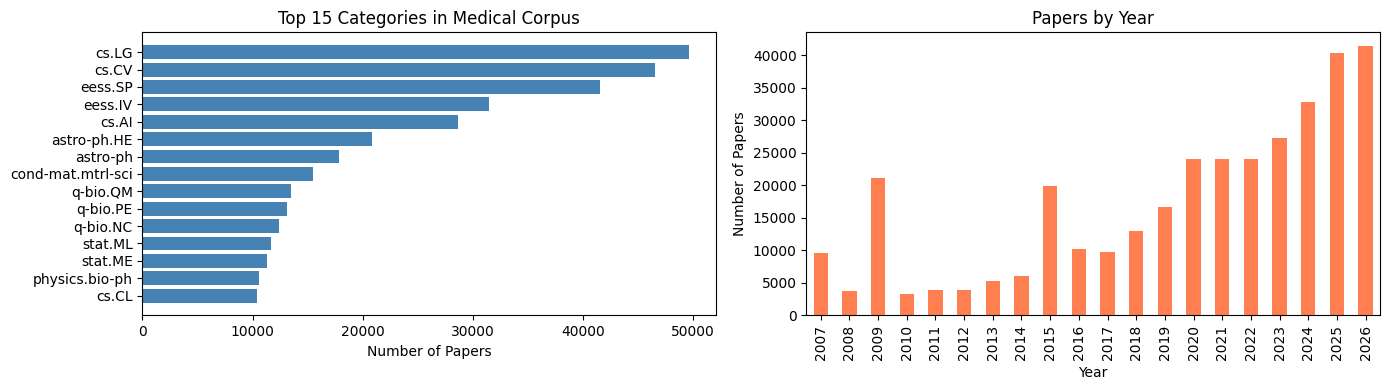

📈 Plot saved to Drive


In [15]:
import matplotlib.pyplot as plt
print(f"📊 Dataset Overview")
print(f"{'─'*40}")
print(f"  Total papers   : {len(df):,}")
print(f"  Date range     : {df['year'].min()} – {df['year'].max()}")
print(f"  Avg word count : {df['token_count'].mean():.0f} words")
print(f"  Min word count : {df['token_count'].min()}")
print(f"  Max word count : {df['token_count'].max()}")
print()
print(df.head(3)[['paper_id','title','categories','year','token_count']].to_string())
# Category distribution
all_cats = []
for cats in df['categories'].str.split():
    all_cats.extend(cats)
from collections import Counter
cat_counts = Counter(all_cats).most_common(15)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Category bar chart
cats, counts = zip(*cat_counts)
axes[0].barh(cats[::-1], counts[::-1], color='steelblue')
axes[0].set_xlabel('Number of Papers')
axes[0].set_title('Top 15 Categories in Medical Corpus')
# Year distribution
df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Papers')
axes[1].set_title('Papers by Year')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RAG/results/dataset_overview.png', dpi=150)
plt.show()
print("📈 Plot saved to Drive")

###  10 — Abstract Length Distribution

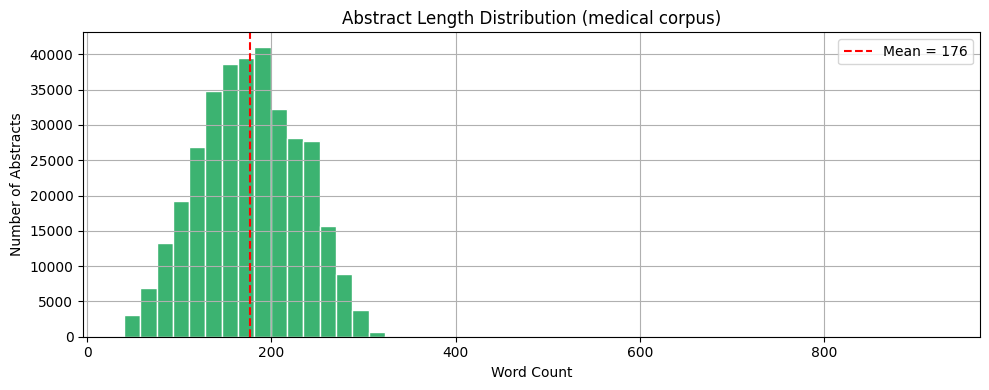

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
df['token_count'].hist(bins=50, ax=ax, color='mediumseagreen', edgecolor='white')
ax.axvline(df['token_count'].mean(), color='red', linestyle='--', label=f"Mean = {df['token_count'].mean():.0f}")
ax.set_xlabel('Word Count')
ax.set_ylabel('Number of Abstracts')
ax.set_title('Abstract Length Distribution (medical corpus)')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RAG/results/abstract_length_dist.png', dpi=150)
plt.show()

###  11 — Final Sanity Check & Summary

In [17]:
print("🔍 Final Sanity Check")
print(f"{'─'*40}")
print(f"  Null values:\n{df.isnull().sum()}\n")
print(f"  Duplicate paper_ids: {df['paper_id'].duplicated().sum()}")
print(f"  Papers with DOI    : {df['doi'].astype(bool).sum():,} ({100*df['doi'].astype(bool).mean():.1f}%)")
print()
# Show 3 random samples
print("📄 3 Random Samples:")
for _, row in df.sample(3, random_state=42).iterrows():
    print(f"\n  [{row['paper_id']}] {row['title'][:70]}")
    print(f"  Categories : {row['categories']}")
    print(f"  Year       : {row['year']}  |  Words: {row['token_count']}")
    print(f"  Abstract   : {row['abstract'][:200]}...")
print(f"\n{'='*50}")
print(f"✅ Notebook 1 Complete!")
print(f"   Processed data saved to:")
print(f"   {PROCESSED_PATH}")
print(f"\n   Next → Open Notebook 2: Embedding & FAISS Index")
print(f"{'='*50}")

🔍 Final Sanity Check
────────────────────────────────────────
  Null values:
chunk_id            0
paper_id            0
title               0
abstract            0
categories          0
authors             0
doi            205066
arxiv_url           0
year                0
token_count         0
dtype: int64

  Duplicate paper_ids: 0
  Papers with DOI    : 135,612 (39.8%)

📄 3 Random Samples:

  [cond-mat/0403168] Unified treatment of fluorescence and Raman scattering processes near 
  Categories : cond-mat.other
  Year       : 2007  |  Words: 81
  Abstract   : We present a general model study of surface-enhanced resonant Raman scattering and fluorescence focusing on the interplay between electromagnetic effects and the molecular dynamics. Our model molecule...

  [2011.14378] Detectability assessment of an x-ray imaging system using the nodes in
  Categories : physics.med-ph physics.data-an
  Year       : 2021  |  Words: 272
  Abstract   : Purpose: Using linear transformation of the d

## PHASE 2: Embedding & FAISS Indexing

###  1 — Mount Drive & Check GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')
# Verify GPU is attached
!nvidia-smi
print("\n✅ Drive mounted and GPU checked.")
print("If you don't see a GPU table above, change your runtime settings!")

Mounted at /content/drive
Sat Sep 12 07:48:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------

###  2 — Install Dependencies

In [2]:
!pip install -q sentence-transformers faiss-cpu pandas pyarrow numpy
print("✅ Dependencies installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 76.7 MB/s eta 0:00:00
✅ Dependencies installed.


###  3 — Load Cleaned Data

In [3]:
import pandas as pd
import numpy as np  # FIX 1: was missing, needed for embeddings.astype('float32') in Cell 6
import os
PROCESSED_PATH  = '/content/drive/MyDrive/RAG/data/processed/medical_papers.parquet'
INDEX_DIR       = '/content/drive/MyDrive/RAG/index'
EMBEDDINGS_PATH = f'{INDEX_DIR}/embeddings.npy'   # FIX 2: checkpoint so we never re-embed
METADATA_PATH   = f'{INDEX_DIR}/chunks_metadata.parquet'
FAISS_PATH      = f'{INDEX_DIR}/faiss_index.bin'
os.makedirs(INDEX_DIR, exist_ok=True)
print("📂 Loading data...")
df = pd.read_parquet(PROCESSED_PATH)
SAMPLE_SIZE = 100000
if len(df) > SAMPLE_SIZE:
    print(f"Downsampling from {len(df):,} → {SAMPLE_SIZE:,} papers for faster processing...")
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
# Save the sampled metadata right away so it's in sync with whatever we embed
df.to_parquet(METADATA_PATH, index=False)
print(f"\n✅ Loaded {len(df):,} papers ready for embedding.")
print(df.head(2)[['paper_id', 'title']])

📂 Loading data...
Downsampling from 340,678 → 100,000 papers for faster processing...

✅ Loaded 100,000 papers ready for embedding.
           paper_id                                              title
0  cond-mat/0403168  Unified treatment of fluorescence and Raman sc...
1        2011.14378  Detectability assessment of an x-ray imaging s...


###  4 — Initialize the Embedding Model

In [4]:
import torch
from sentence_transformers import SentenceTransformer
MODEL_NAME = 'all-MiniLM-L6-v2'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🤖 Loading model: {MODEL_NAME} on [{device.upper()}]...")
model = SentenceTransformer(MODEL_NAME, device=device)
print("✅ Model loaded successfully.")

🤖 Loading model: all-MiniLM-L6-v2 on [CUDA]...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded successfully.


###  5 — Encode Abstracts (GPU Heavy Lifting)

In [5]:
if os.path.exists(EMBEDDINGS_PATH):
    print(f"⚡ Embeddings checkpoint found — loading from Drive (skipping GPU step)...")
    embeddings = np.load(EMBEDDINGS_PATH)
    print(f"✅ Loaded embeddings shape: {embeddings.shape}")
else:
    print(f"🚀 Embedding {len(df):,} abstracts on {device.upper()} — ~10-15 min on T4...")
    texts = df['abstract'].tolist()
    embeddings = model.encode(
        texts,
        batch_size=256,
        show_progress_bar=True,
        normalize_embeddings=True  # Required for cosine similarity via IndexFlatIP
    )
    # Save checkpoint immediately — if Colab resets after this, you never re-embed
    np.save(EMBEDDINGS_PATH, embeddings)
    print(f"\n✅ Embedding complete! Shape: {embeddings.shape}")
    print(f"💾 Checkpoint saved → {EMBEDDINGS_PATH}")

🚀 Embedding 100,000 abstracts on CUDA — ~10-15 min on T4...


Batches:   0%|          | 0/391 [00:00<?, ?it/s]


✅ Embedding complete! Shape: (100000, 384)
💾 Checkpoint saved → /content/drive/MyDrive/RAG/index/embeddings.npy


###  6 — Build and Save the FAISS Index

In [6]:
import faiss
# FIX 3: Skip rebuilding if index already exists on Drive
if os.path.exists(FAISS_PATH):
    print(f"⚡ FAISS index already exists — loading from Drive...")
    index = faiss.read_index(FAISS_PATH)
    print(f"✅ Loaded index with {index.ntotal:,} vectors")
else:
    print("🏗️  Building FAISS Index...")
    d = embeddings.shape[1]  # 384 dimensions for MiniLM
    index = faiss.IndexFlatIP(d)
    index.add(embeddings.astype('float32'))
    print(f"✅ Index built. Total vectors: {index.ntotal:,}")
    print(f"💾 Saving FAISS index → {FAISS_PATH}")
    faiss.write_index(index, FAISS_PATH)
print("\n🎉 DONE! Index + metadata + embeddings saved to Google Drive.")
print("If Colab resets, just run Cells 1→3→6 to reload everything in ~30 seconds.")

🏗️  Building FAISS Index...
✅ Index built. Total vectors: 100,000
💾 Saving FAISS index → /content/drive/MyDrive/RAG/index/faiss_index.bin

🎉 DONE! Index + metadata + embeddings saved to Google Drive.
If Colab resets, just run Cells 1→3→6 to reload everything in ~30 seconds.


###  7 — Smoke Test (Verify Everything Works)

In [7]:
print("🧪 Running smoke test...\n")
metadata = pd.read_parquet(METADATA_PATH)
test_query = "deep learning for cancer detection from medical images"
# Embed the test query
q_emb = model.encode([test_query], normalize_embeddings=True).astype('float32')
# Search the index
scores, indices = index.search(q_emb, k=3)
print(f"Query: '{test_query}'\n")
print("Top 3 Results:")
for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), 1):
    row = metadata.iloc[idx]
    print(f"\n  [{rank}] Score: {score:.4f}")
    print(f"  Title: {row['title'][:80]}")
    print(f"  URL  : {row['arxiv_url']}")
print("\n✅ Smoke test passed! Retrieval is working correctly.")
print("\n➡️  Proceed to Notebook 3: RAG Pipeline (Retrieval + Re-ranking + Groq LLM)")

🧪 Running smoke test...

Query: 'deep learning for cancer detection from medical images'

Top 3 Results:

  [1] Score: 0.7251
  Title: Computer-Aided Cancer Diagnosis via Machine Learning and Deep Learning:   A comp
  URL  : https://arxiv.org/abs/2210.11943

  [2] Score: 0.7194
  Title: A survey on deep learning approaches for breast cancer diagnosis
  URL  : https://arxiv.org/abs/2109.08853

  [3] Score: 0.6935
  Title: Robust breast cancer detection in mammography and digital breast   tomosynthesis
  URL  : https://arxiv.org/abs/1912.11027

✅ Smoke test passed! Retrieval is working correctly.

➡️  Proceed to Notebook 3: RAG Pipeline (Retrieval + Re-ranking + Groq LLM)


## PHASE 3: RAG Pipeline (Retrieval + Re-ranking + Groq LLM)

###  1 — Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted.")

Mounted at /content/drive
✅ Drive mounted.


###  2 — Install Dependencies

In [2]:
!pip install -q sentence-transformers faiss-cpu pandas pyarrow numpy groq
print("✅ Dependencies installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 11.6 MB/s eta 0:00:00
✅ Dependencies installed.


###  3 — Load FAISS Index + Metadata

In [3]:
import faiss
import pandas as pd
import numpy as np
import os
INDEX_DIR     = '/content/drive/MyDrive/RAG/index'
FAISS_PATH    = f'{INDEX_DIR}/faiss_index.bin'
METADATA_PATH = f'{INDEX_DIR}/chunks_metadata.parquet'
print("📂 Loading FAISS index from Drive...")
index = faiss.read_index(FAISS_PATH)
print(f"   ✅ Index loaded — {index.ntotal:,} vectors")
print("📂 Loading metadata from Drive...")
metadata = pd.read_parquet(METADATA_PATH)
print(f"   ✅ Metadata loaded — {len(metadata):,} rows")
# Sanity check: index and metadata MUST have the same count
assert index.ntotal == len(metadata), \
    f"❌ Mismatch! Index has {index.ntotal} vectors but metadata has {len(metadata)} rows."
print("\n✅ Index and metadata are in sync. Ready to retrieve.")

📂 Loading FAISS index from Drive...
   ✅ Index loaded — 100,000 vectors
📂 Loading metadata from Drive...
   ✅ Metadata loaded — 100,000 rows

✅ Index and metadata are in sync. Ready to retrieve.


###  4 — Load Bi-Encoder (Query Embedder)

In [4]:
import torch
from sentence_transformers import SentenceTransformer
# Must use the SAME model we used in Notebook 2 to embed the corpus.
BI_ENCODER_MODEL = 'all-MiniLM-L6-v2'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🤖 Loading bi-encoder: {BI_ENCODER_MODEL} on [{device.upper()}]...")
bi_encoder = SentenceTransformer(BI_ENCODER_MODEL, device=device)
print("✅ Bi-encoder loaded.")

🤖 Loading bi-encoder: all-MiniLM-L6-v2 on [CPU]...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Bi-encoder loaded.


###  5 — Load Cross-Encoder Re-ranker

In [6]:
from sentence_transformers import CrossEncoder
# This model was specifically trained to score (query, passage) relevance pairs.
# It is much more accurate than the bi-encoder but slower (runs on all 50 candidates).
CROSS_ENCODER_MODEL = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
print(f"🤖 Loading cross-encoder re-ranker: {CROSS_ENCODER_MODEL}...")
cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL)
print("✅ Cross-encoder loaded.")


🤖 Loading cross-encoder re-ranker: cross-encoder/ms-marco-MiniLM-L-6-v2...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

✅ Cross-encoder loaded.


###  6 — Configure Groq API

In [9]:
from google.colab import userdata
from groq import Groq
# Load API key from Colab Secrets (🔑 icon in left sidebar)
# Make sure you have added GROQ_API_KEY in your secrets
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
groq_client  = Groq(api_key=GROQ_API_KEY)
# We use openai/gpt-oss-120b:
#   - Free on Groq (current stable model as of 2026)
#   - 120B parameters = excellent medical reasoning
#   - Very fast (Groq's LPU hardware)
GROQ_MODEL = "openai/gpt-oss-120b"
# Quick connectivity test
print(f"🔌 Testing Groq API connection with model: {GROQ_MODEL}...")
test_response = groq_client.chat.completions.create(
    model=GROQ_MODEL,
    messages=[{"role": "user", "content": "Reply with only: OK"}],
    max_tokens=5,
)
print(f"   API response: {test_response.choices[0].message.content}")
print("✅ Groq API is connected and working.")

🔌 Testing Groq API connection with model: openai/gpt-oss-120b...
   API response: 
✅ Groq API is connected and working.


###  7 — Define the Retrieval Function

In [10]:
def retrieve(query: str, top_k: int = 50) -> pd.DataFrame:
    """
    Stage 1: Bi-encoder retrieval.
    Embeds the query, searches the FAISS index, returns top_k candidates.
    Fast because it is just a vector similarity lookup.
    """
    # Embed the query (must be normalized, same as corpus embeddings)
    q_emb = bi_encoder.encode([query], normalize_embeddings=True).astype('float32')
    # Search FAISS index
    scores, indices = index.search(q_emb, top_k)
    # Build result DataFrame
    results = metadata.iloc[indices[0]].copy()
    results['bi_encoder_score'] = scores[0]
    results = results.reset_index(drop=True)
    return results
# Quick test
print("🧪 Testing retrieval...")
test_candidates = retrieve("COVID-19 treatment effectiveness")
print(f"   Retrieved {len(test_candidates)} candidates")
print(f"   Top result: {test_candidates.iloc[0]['title'][:70]}")
print("✅ Retrieval function working.")


🧪 Testing retrieval...
   Retrieved 50 candidates
   Top result: Evaluating Policies Early in a Pandemic: Bounding Policy Effects with 
✅ Retrieval function working.


###  8 — Define the Re-ranking Function

In [11]:
def rerank(query: str, candidates: pd.DataFrame, top_k: int = 5) -> pd.DataFrame:
    """
    Stage 2: Cross-encoder re-ranking.
    Scores each (query, candidate) pair jointly — much more accurate than bi-encoder.
    Keeps only the top_k most relevant chunks.
    """
    # Build list of [query, abstract] pairs for the cross-encoder
    pairs = [[query, row['abstract']] for _, row in candidates.iterrows()]
    # Score all pairs
    rerank_scores = cross_encoder.predict(pairs)
    # Attach scores and sort descending
    candidates = candidates.copy()
    candidates['rerank_score'] = rerank_scores
    reranked = candidates.nlargest(top_k, 'rerank_score').reset_index(drop=True)
    return reranked
# Quick test
print("🧪 Testing re-ranker...")
test_candidates = retrieve("COVID-19 treatment effectiveness", top_k=50)
test_reranked   = rerank("COVID-19 treatment effectiveness", test_candidates, top_k=5)
print(f"   After re-ranking, top result:")
print(f"   Score: {test_reranked.iloc[0]['rerank_score']:.4f} | {test_reranked.iloc[0]['title'][:70]}")
print("✅ Re-ranker working.")


🧪 Testing re-ranker...
   After re-ranking, top result:
   Score: 4.9743 | How Robust are the Estimated Effects of Nonpharmaceutical Intervention
✅ Re-ranker working.


###  9 — Define the Prompt Builder

In [12]:
SYSTEM_PROMPT = """You are a medical research assistant with expertise in biomedical literature.
Your task is to answer questions based ONLY on the research paper abstracts provided to you.
Rules you MUST follow:
1. Ground every claim in the provided context. Do NOT use outside knowledge.
2. Cite sources inline using [1], [2], etc. after each relevant sentence.
3. If the answer is not in the provided context, say exactly:
   "The provided papers do not contain enough information to answer this question."
4. Keep your answer concise and factual — 3 to 5 sentences maximum.
5. At the end, list the cited papers under a "Sources:" heading."""
from typing import Tuple
def build_context_and_prompt(query: str, top_chunks: pd.DataFrame) -> Tuple[str, str]:
    """
    Formats the top chunks into a numbered context block
    and returns (system_prompt, user_message).
    """
    context_parts = []
    for i, (_, row) in enumerate(top_chunks.iterrows(), 1):
        context_parts.append(
            f"[{i}] Title: {row['title']}\n"
            f"    URL: {row['arxiv_url']}\n"
            f"    Abstract: {row['abstract']}"
        )
    context_block = "\n\n".join(context_parts)
    user_message = (
        f"Context Papers:\n\n{context_block}\n\n"
        f"---\n\n"
        f"Question: {query}\n\n"
        f"Answer (cite sources with [1], [2], etc.):"
    )
    return SYSTEM_PROMPT, user_message

###  10 — Define the Generator Function

In [13]:

def generate_answer(query: str, top_chunks: pd.DataFrame) -> str:
    """
    Calls the Groq API (Llama 3.1 70B) with the formatted context and query.
    Returns the generated answer string.
    """
    system_prompt, user_message = build_context_and_prompt(query, top_chunks)
    response = groq_client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_message},
        ],
        temperature=0.1,    # Low temperature = more factual, less creative
        max_tokens=1024,
    )
    return response.choices[0].message.content

###  11 — Build the Full End-to-End RAG Function

In [14]:
def rag_query(
    question: str,
    top_k_retrieve: int = 50,
    top_k_final: int    = 5,
    verbose: bool       = True,
) -> dict:
    """
    Full RAG pipeline:
      1. Bi-encoder retrieval  (top_k_retrieve candidates from FAISS)
      2. Cross-encoder re-rank (top_k_final final chunks)
      3. Groq LLM generation   (grounded answer with citations)
    Returns a dict with keys: answer, sources, top_chunks
    """
    if verbose:
        print(f"🔍 Step 1: Retrieving top-{top_k_retrieve} candidates...")
    candidates = retrieve(question, top_k=top_k_retrieve)
    if verbose:
        print(f"⚖️  Step 2: Re-ranking to top-{top_k_final} chunks...")
    top_chunks = rerank(question, candidates, top_k=top_k_final)
    if verbose:
        print(f"🤖 Step 3: Generating answer with Groq ({GROQ_MODEL})...")
    answer = generate_answer(question, top_chunks)
    # Build a clean sources list for display
    sources = []
    for i, (_, row) in enumerate(top_chunks.iterrows(), 1):
        sources.append({
            "rank":          i,
            "title":         row['title'],
            "url":           row['arxiv_url'],
            "rerank_score":  round(float(row['rerank_score']), 4),
        })
    return {
        "question":   question,
        "answer":     answer,
        "sources":    sources,
        "top_chunks": top_chunks,
    }
def display_result(result: dict):
    """Pretty-prints a RAG result."""
    print("=" * 65)
    print(f"❓ QUESTION:\n   {result['question']}")
    print("=" * 65)
    print(f"\n📝 ANSWER:\n\n{result['answer']}")
    print("\n" + "─" * 65)
    print("📚 RETRIEVED SOURCES (after re-ranking):")
    for s in result['sources']:
        print(f"  [{s['rank']}] Score: {s['rerank_score']:.4f} | {s['title'][:65]}")
        print(f"       {s['url']}")
    print("=" * 65)

###  12 — Run 5 Test Queries

In [15]:
test_questions = [
    "What deep learning methods are used for early detection of lung cancer in CT scans?",
    "How effective are mRNA vaccines against COVID-19 variants?",
    "What are the main biomarkers used to predict Alzheimer's disease progression?",
    "What is the role of CRISPR in treating genetic blood disorders?",
    "How does federated learning help preserve patient privacy in medical AI?",
]
print("🚀 Running 5 test queries through the full RAG pipeline...\n")
results_log = []
for i, question in enumerate(test_questions, 1):
    print(f"\n{'#'*65}")
    print(f"  TEST {i} of {len(test_questions)}")
    print(f"{'#'*65}")
    result = rag_query(question, top_k_retrieve=50, top_k_final=5, verbose=True)
    display_result(result)
    results_log.append({
        "question": result['question'],
        "answer":   result['answer'],
        "sources":  result['sources'],
    })
    print()
    # Small pause between queries to respect Groq free-tier rate limits
    # (Free tier: ~30 requests/min. 2 seconds between calls keeps us safely under.)
    if i < len(test_questions):
        import time
        time.sleep(2)
print("\n✅ All 5 test queries completed successfully!")

🚀 Running 5 test queries through the full RAG pipeline...


#################################################################
  TEST 1 of 5
#################################################################
🔍 Step 1: Retrieving top-50 candidates...
⚖️  Step 2: Re-ranking to top-5 chunks...
🤖 Step 3: Generating answer with Groq (openai/gpt-oss-120b)...
❓ QUESTION:
   What deep learning methods are used for early detection of lung cancer in CT scans?

📝 ANSWER:

Several deep‑learning approaches have been applied to early lung‑cancer detection from CT scans. A hybrid model combining convolutional neural networks with support‑vector machines was trained on CT images for tumor classification [1]. A novel “Channel Squeeze U‑Structure” network integrates shallow processing, channel‑residual and channel‑squeeze modules to detect and segment small nodules [2]. Another hybrid architecture embeds Chebyshev polynomial expansions into CNN layers to capture high‑frequency features and improve benign‑

###  13 — Save Results Log to *Drive*

In [16]:
import json
RESULTS_PATH = '/content/drive/MyDrive/RAG/results/pipeline_test_results.json'
os.makedirs('/content/drive/MyDrive/RAG/results', exist_ok=True)
with open(RESULTS_PATH, 'w', encoding='utf-8') as f:
    json.dump(results_log, f, indent=2, ensure_ascii=False)
print(f"💾 Test results saved → {RESULTS_PATH}")
print("\n✅ Notebook 3 Complete!")
print("➡️  Proceed to Notebook 4: Evaluation (Recall@k, BERTScore, Ablation Study)")

💾 Test results saved → /content/drive/MyDrive/RAG/results/pipeline_test_results.json

✅ Notebook 3 Complete!
➡️  Proceed to Notebook 4: Evaluation (Recall@k, BERTScore, Ablation Study)


## PHASE 4: Evaluation — Recall@k, BERTScore and Ablation Study

###  1 — Mount Drive

In [17]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted.


###  2 — Install Dependencies

In [18]:
!pip install -q sentence-transformers faiss-cpu pandas pyarrow numpy groq bert-score
print("✅ All dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.8 MB/s eta 0:00:00
✅ All dependencies installed.


###  3 — Load Everything from Drive

In [19]:
import faiss
import pandas as pd
import numpy as np
import os
import json
import time
INDEX_DIR     = '/content/drive/MyDrive/RAG/index'
FAISS_PATH    = f'{INDEX_DIR}/faiss_index.bin'
METADATA_PATH = f'{INDEX_DIR}/chunks_metadata.parquet'
RESULTS_DIR   = '/content/drive/MyDrive/RAG/results'
EVAL_SET_PATH = '/content/drive/MyDrive/RAG/data/eval/eval_set.json'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(EVAL_SET_PATH), exist_ok=True)
print("📂 Loading FAISS index...")
index = faiss.read_index(FAISS_PATH)
print(f"   ✅ {index.ntotal:,} vectors")
print("📂 Loading metadata...")
metadata = pd.read_parquet(METADATA_PATH)
print(f"   ✅ {len(metadata):,} rows")
assert index.ntotal == len(metadata), "❌ Index/metadata size mismatch!"
print("\n✅ All data loaded and in sync.")

📂 Loading FAISS index...
   ✅ 100,000 vectors
📂 Loading metadata...
   ✅ 100,000 rows

✅ All data loaded and in sync.


###  4 — Load Models + *Groq*

In [20]:
import torch
from sentence_transformers import SentenceTransformer, CrossEncoder
from google.colab import userdata
from groq import Groq
from typing import Tuple
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🤖 Loading bi-encoder on [{device.upper()}]...")
bi_encoder    = SentenceTransformer('all-MiniLM-L6-v2', device=device)
print("🤖 Loading cross-encoder re-ranker...")
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
print("🔌 Connecting to Groq...")
groq_client = Groq(api_key=userdata.get('GROQ_API_KEY'))
GROQ_MODEL  = "openai/gpt-oss-120b"
# Verify Groq
ping = groq_client.chat.completions.create(
    model=GROQ_MODEL,
    messages=[{"role": "user", "content": "Reply with only: OK"}],
    max_tokens=5
)
print(f"   Groq ping: {ping.choices[0].message.content}")
print("✅ All models ready.")


🤖 Loading bi-encoder on [CPU]...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

🤖 Loading cross-encoder re-ranker...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

🔌 Connecting to Groq...
   Groq ping: 
✅ All models ready.


###  5 — Rebuild RAG Functions

In [21]:
def retrieve(query: str, top_k: int = 50) -> pd.DataFrame:
    q_emb = bi_encoder.encode([query], normalize_embeddings=True).astype('float32')
    scores, indices = index.search(q_emb, top_k)
    results = metadata.iloc[indices[0]].copy()
    results['bi_encoder_score'] = scores[0]
    return results.reset_index(drop=True)
def rerank(query: str, candidates: pd.DataFrame, top_k: int = 5) -> pd.DataFrame:
    pairs = [[query, row['abstract']] for _, row in candidates.iterrows()]
    scores = cross_encoder.predict(pairs)
    candidates = candidates.copy()
    candidates['rerank_score'] = scores
    return candidates.nlargest(top_k, 'rerank_score').reset_index(drop=True)
SYSTEM_PROMPT = """You are a medical research assistant with expertise in biomedical literature.
Answer questions based ONLY on the research paper abstracts provided.
Rules:
1. Ground every claim in the provided context. Do NOT use outside knowledge.
2. Cite sources inline using [1], [2], etc.
3. If the answer is not in context, say: "The provided papers do not contain enough information."
4. Keep answers concise — 3 to 5 sentences.
5. End with a Sources: section."""
def generate_answer(query: str, top_chunks: pd.DataFrame) -> str:
    context_parts = []
    for i, (_, row) in enumerate(top_chunks.iterrows(), 1):
        context_parts.append(f"[{i}] Title: {row['title']}\n    Abstract: {row['abstract']}")
    context_block = "\n\n".join(context_parts)
    user_message  = f"Context Papers:\n\n{context_block}\n\n---\n\nQuestion: {query}\n\nAnswer:"
    response = groq_client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_message},
        ],
        temperature=0.1,
        max_tokens=1024,
    )
    return response.choices[0].message.content
def rag_query(question, top_k_retrieve=50, top_k_final=5, use_reranker=True):
    candidates = retrieve(question, top_k=top_k_retrieve)
    if use_reranker:
        top_chunks = rerank(question, candidates, top_k=top_k_final)
    else:
        top_chunks = candidates.head(top_k_final)
    answer = generate_answer(question, top_chunks)
    return {"answer": answer, "top_chunks": top_chunks}
print("✅ RAG functions rebuilt.")


✅ RAG functions rebuilt.


###  6 — Auto-Generate the Eval Set via Groq

In [23]:
import os
os.remove('/content/drive/MyDrive/RAG/data/eval/eval_set.json')

In [24]:

EVAL_SET_SIZE = 50
if os.path.exists(EVAL_SET_PATH):
    print(f"⚡ Eval set already exists — loading from Drive...")
    with open(EVAL_SET_PATH, 'r') as f:
        eval_set = json.load(f)
    print(f"   Loaded {len(eval_set)} eval pairs.")
else:
    print(f"🔨 Auto-generating {EVAL_SET_SIZE}-pair eval set using Groq...\n")
    print("   This will take ~5 minutes (1 API call per paper).\n")
    # Sample papers that are likely to have clear, answerable content.
    # We prefer papers with longer abstracts (more content = better questions).
    MEDICAL_TITLE_KEYWORDS = ['cancer','tumor','disease','clinical','patient',
                          'covid','drug','brain','cardiac','diagnosis',
                          'therapy','genomic','medical','health','neural']
    medical_mask = metadata['title'].str.lower().str.contains('|'.join(MEDICAL_TITLE_KEYWORDS), na=False)
    sample_pool = metadata[medical_mask & (metadata['token_count'] >= 100)].sample(
    n=min(300, medical_mask.sum()), random_state=99   # bigger pool = more attempts
    ).reset_index(drop=True)
    QUESTION_GEN_PROMPT = """You are building a Q&A evaluation dataset from a medical research abstract.
Given the abstract below, generate exactly ONE specific factual question that:
- Has a clear, explicit answer contained within the abstract
- Asks about a specific finding, method, result, or number
- Cannot be answered from general medical knowledge alone — requires reading this abstract
Then provide the expected answer (a short phrase or sentence from the abstract).
Respond ONLY as valid JSON with this exact format:
{{"question": "...", "answer": "..."}}
Abstract:
{abstract}"""
    eval_set = []
    failed   = 0
    for i, (_, row) in enumerate(sample_pool.iterrows()):
        if len(eval_set) >= EVAL_SET_SIZE:
            break
        try:
            response = groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{
                    "role": "user",
                    "content": QUESTION_GEN_PROMPT.format(abstract=row['abstract'][:1200])
                }],
                temperature=0.3,
                max_tokens=256,
            )
            raw = response.choices[0].message.content.strip()
            # Parse JSON (handle markdown code fences if present)
            raw = raw.replace("```json", "").replace("```", "").strip()
            parsed = json.loads(raw)
            if "question" in parsed and "answer" in parsed:
                eval_set.append({
                    "id":                    len(eval_set) + 1,
                    "question":              parsed["question"],
                    "reference_answer":      parsed["answer"],
                    "ground_truth_paper_id": row['paper_id'],
                    "ground_truth_chunk_id": row['chunk_id'],
                    "paper_title":           row['title'],
                })
                print(f"  [{len(eval_set):2d}/{EVAL_SET_SIZE}] ✅ {parsed['question'][:70]}")
            else:
                failed += 1
        except (json.JSONDecodeError, KeyError):
            failed += 1
        # Respect Groq rate limits
        time.sleep(1.5)
    print(f"\n✅ Generated {len(eval_set)} eval pairs ({failed} failed/skipped)")
    # Save to Drive
    with open(EVAL_SET_PATH, 'w') as f:
        json.dump(eval_set, f, indent=2)
    print(f"💾 Saved → {EVAL_SET_PATH}")
# Quick look at 3 samples
print("\n📄 Sample Eval Pairs:")
for item in eval_set[:3]:
    print(f"\n  [{item['id']}] Q: {item['question']}")
    print(f"       A: {item['reference_answer'][:100]}")
    print(f"       Source: {item['paper_title'][:60]}")

🔨 Auto-generating 50-pair eval set using Groq...

   This will take ~5 minutes (1 API call per paper).

  [ 1/50] ✅ Which three open-weight large language models were evaluated in the be
  [ 2/50] ✅ What does the evaluation with synthetic and real-world multicellular s
  [ 3/50] ✅ What accuracy did the multimodal model achieve in classifying MRI scan
  [ 4/50] ✅ How many control nodes were identified by the framework?
  [ 5/50] ✅ What type of neural network architecture is employed in the proposed P
  [ 6/50] ✅ How does the abstract define FLASH radiation therapy (FLASH-RT)?
  [ 7/50] ✅ What concept do the authors use to elucidate the mechanism that forces
  [ 8/50] ✅ What are the two modules that compose the CATS Net model?
  [ 9/50] ✅ What F1-Score did the model achieve for real-word error detection?
  [10/50] ✅ What framework was employed to extend the hybrid semi-implicit and exp
  [11/50] ✅ How many clinical notes were included in the curated DDx dataset?
  [12/50] ✅ According to 

###  7 — Compute Recall@k and MRR

In [25]:
print("📊 Computing Retrieval Metrics (Recall@k and MRR)...")
print("   This runs one FAISS query per eval item — very fast.\n")
K_VALUES = [1, 3, 5, 10, 20]
# For each eval item, retrieve top-20 and record where the truth appears
retrieval_results = []
for item in eval_set:
    gt_chunk_id = item['ground_truth_chunk_id']
    # Retrieve top-20 candidates (no re-ranking for pure retrieval metrics)
    candidates = retrieve(item['question'], top_k=20)
    retrieved_chunk_ids = candidates['chunk_id'].tolist()
    # Find the rank of the ground truth (1-indexed, 0 if not found)
    rank = 0
    for r, cid in enumerate(retrieved_chunk_ids, 1):
        if cid == gt_chunk_id:
            rank = r
            break
    retrieval_results.append({
        "question":       item['question'],
        "gt_chunk_id":    gt_chunk_id,
        "retrieved_ids":  retrieved_chunk_ids,
        "rank_of_truth":  rank,   # 0 means not found in top-20
    })
# Compute Recall@k
recall_at_k = {}
for k in K_VALUES:
    hits = sum(1 for r in retrieval_results if 0 < r['rank_of_truth'] <= k)
    recall_at_k[k] = hits / len(retrieval_results)
# Compute MRR
mrr = sum(
    1.0 / r['rank_of_truth'] if r['rank_of_truth'] > 0 else 0.0
    for r in retrieval_results
) / len(retrieval_results)
print("=" * 42)
print("    Bi-Encoder Retrieval Metrics")
print("=" * 42)
for k in K_VALUES:
    bar = "█" * int(recall_at_k[k] * 20)
    print(f"  Recall@{k:2d} : {recall_at_k[k]:.3f}  {bar}")
print(f"  MRR       : {mrr:.3f}")
print("=" * 42)


📊 Computing Retrieval Metrics (Recall@k and MRR)...
   This runs one FAISS query per eval item — very fast.

    Bi-Encoder Retrieval Metrics
  Recall@ 1 : 0.300  ██████
  Recall@ 3 : 0.400  ████████
  Recall@ 5 : 0.440  ████████
  Recall@10 : 0.520  ██████████
  Recall@20 : 0.660  █████████████
  MRR       : 0.377


###  8 — Generate RAG Answers for Eval *Set*

In [26]:
print(f"🤖 Generating RAG answers for {len(eval_set)} eval questions...")
print("   This takes ~2-3 minutes (one Groq call per question).\n")
GENERATED_ANSWERS_PATH = f'{RESULTS_DIR}/generated_answers.json'
if os.path.exists(GENERATED_ANSWERS_PATH):
    print("⚡ Generated answers already exist — loading from Drive...")
    with open(GENERATED_ANSWERS_PATH, 'r') as f:
        answer_records = json.load(f)
    print(f"   Loaded {len(answer_records)} answer records.")
else:
    answer_records = []
    for i, item in enumerate(eval_set, 1):
        print(f"  [{i:2d}/{len(eval_set)}] Answering: {item['question'][:60]}...")
        try:
            result = rag_query(
                item['question'],
                top_k_retrieve=50,
                top_k_final=5,
                use_reranker=True
            )
            # rerank_score only exists if use_reranker=True
            rerank_scores = (
                result['top_chunks']['rerank_score'].tolist()
                if 'rerank_score' in result['top_chunks'].columns
                else []
            )
            answer_records.append({
                "id":               item['id'],
                "question":         item['question'],
                "reference_answer": item['reference_answer'],
                "generated_answer": result['answer'],
                "retrieved_chunk_ids": result['top_chunks']['chunk_id'].tolist(),
                "rerank_scores":       rerank_scores,
            })
        except Exception as e:
            print(f"     ⚠️  Failed: {e}")
            answer_records.append({
                "id": item['id'],
                "question": item['question'],
                "reference_answer": item['reference_answer'],
                "generated_answer": "ERROR",
                "retrieved_chunk_ids": [],
                "rerank_scores": [],
            })
        if i < len(eval_set):
            time.sleep(2)  # Groq rate limit
    with open(GENERATED_ANSWERS_PATH, 'w') as f:
        json.dump(answer_records, f, indent=2)
    print(f"\n💾 Saved → {GENERATED_ANSWERS_PATH}")
print("\n✅ Answer generation complete.")

🤖 Generating RAG answers for 50 eval questions...
   This takes ~2-3 minutes (one Groq call per question).

  [ 1/50] Answering: Which three open-weight large language models were evaluated...
  [ 2/50] Answering: What does the evaluation with synthetic and real-world multi...
  [ 3/50] Answering: What accuracy did the multimodal model achieve in classifyin...
  [ 4/50] Answering: How many control nodes were identified by the framework?...
  [ 5/50] Answering: What type of neural network architecture is employed in the ...
  [ 6/50] Answering: How does the abstract define FLASH radiation therapy (FLASH-...
  [ 7/50] Answering: What concept do the authors use to elucidate the mechanism t...
  [ 8/50] Answering: What are the two modules that compose the CATS Net model?...
  [ 9/50] Answering: What F1-Score did the model achieve for real-word error dete...
  [10/50] Answering: What framework was employed to extend the hybrid semi-implic...
  [11/50] Answering: How many clinical notes were

###  9 — Compute BERTScore

In [27]:
from bert_score import score as bert_score_fn
print("📊 Computing BERTScore F1 (generated vs. reference answers)...")
print("   Uses RoBERTa to measure semantic similarity — may take 2 min on CPU.\n")
# Filter out any ERROR answers
valid_records    = [r for r in answer_records if r['generated_answer'] != "ERROR"]
generated_texts  = [r['generated_answer']  for r in valid_records]
reference_texts  = [r['reference_answer']  for r in valid_records]
# Compute BERTScore (lang='en' uses roberta-large)
P, R, F1 = bert_score_fn(
    generated_texts,
    reference_texts,
    lang='en',
    verbose=True
)
mean_f1 = F1.mean().item()
mean_p  = P.mean().item()
mean_r  = R.mean().item()
print(f"\n{'=' * 42}")
print(f"    BERTScore Results")
print(f"{'=' * 42}")
print(f"  Precision : {mean_p:.4f}")
print(f"  Recall    : {mean_r:.4f}")
print(f"  F1 Score  : {mean_f1:.4f}  ← main metric")
print(f"{'=' * 42}")
# Attach F1 scores to records for later use
for i, record in enumerate(valid_records):
    record['bertscore_f1'] = F1[i].item()


📊 Computing BERTScore F1 (generated vs. reference answers)...
   Uses RoBERTa to measure semantic similarity — may take 2 min on CPU.



config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 150.17 seconds, 0.33 sentences/sec

    BERTScore Results
  Precision : 0.7886
  Recall    : 0.8934
  F1 Score  : 0.8375  ← main metric


###  10 — Ablation Study

In [38]:
print("🔬 Running Ablation Study...")
print("   4 configurations × Recall@5 + Recall@10\n")
print("   (Using retrieval metrics only — no LLM calls needed, very fast)\n")
ABLATION_CONFIGS = [
    {"name": "No re-ranker  | top_k=25",  "top_k_retrieve": 25,  "use_reranker": False},
    {"name": "No re-ranker  | top_k=50",  "top_k_retrieve": 50,  "use_reranker": False},
    {"name": "With re-ranker| top_k=25",  "top_k_retrieve": 25,  "use_reranker": True},
    {"name": "With re-ranker| top_k=50",  "top_k_retrieve": 50,  "use_reranker": True},
]
ablation_results = []
for config in ABLATION_CONFIGS:
    print(f"  Testing: {config['name']} ...")
    recall_5  = 0
    recall_10 = 0
    mrr_score = 0.0
    for item in eval_set:
        gt_chunk_id = item['ground_truth_chunk_id']
        candidates = retrieve(item['question'], top_k=config['top_k_retrieve'])
        if config['use_reranker']:
            top10 = rerank(item['question'], candidates, top_k=10)
        else:
            top10 = candidates.head(10)
        retrieved_ids = top10['chunk_id'].tolist()
        # Recall@5
        if gt_chunk_id in retrieved_ids[:5]:
            recall_5 += 1
        # Recall@10
        if gt_chunk_id in retrieved_ids[:10]:
            recall_10 += 1
        # MRR
        if gt_chunk_id in retrieved_ids:
            rank = retrieved_ids.index(gt_chunk_id) + 1
            mrr_score += 1.0 / rank
    n = len(eval_set)
    ablation_results.append({
        "config":    config['name'],
        "recall@5":  round(recall_5  / n, 4),
        "recall@10": round(recall_10 / n, 4),
        "mrr":       round(mrr_score / n, 4),
    })
    print(f"     Recall@5={recall_5/n:.3f}  Recall@10={recall_10/n:.3f}  MRR={mrr_score/n:.3f}")
# Save ablation results
ABLATION_PATH = f'{RESULTS_DIR}/ablation_results.json'
with open(ABLATION_PATH, 'w') as f:
    json.dump(ablation_results, f, indent=2)
print(f"\n💾 Saved → {ABLATION_PATH}")

🔬 Running Ablation Study...
   4 configurations × Recall@5 + Recall@10

   (Using retrieval metrics only — no LLM calls needed, very fast)

  Testing: No re-ranker  | top_k=25 ...
     Recall@5=0.440  Recall@10=0.520  MRR=0.368
  Testing: No re-ranker  | top_k=50 ...
     Recall@5=0.440  Recall@10=0.520  MRR=0.368
  Testing: With re-ranker| top_k=25 ...
     Recall@5=0.680  Recall@10=0.680  MRR=0.680
  Testing: With re-ranker| top_k=50 ...
     Recall@5=0.760  Recall@10=0.780  MRR=0.743

💾 Saved → /content/drive/MyDrive/RAG/results/ablation_results.json


###  11 — Print Final Results Table

In [40]:
print("\n" + "="*65)
print("  📊 FINAL EVALUATION RESULTS SUMMARY")
print("="*65)
print(f"\n1️⃣  RETRIEVAL (Bi-encoder, {len(eval_set)} eval questions)")
for k in K_VALUES:
    print(f"     Recall@{k:2d} : {recall_at_k[k]:.3f}")
print(f"     MRR       : {mrr:.3f}")
print(f"\n2️⃣  ANSWER QUALITY ({len(valid_records)} valid answers)")
print(f"     BERTScore F1 : {mean_f1:.4f}")
print(f"\n3️⃣  ABLATION STUDY")
print(f"     {'Configuration':<30} {'R@5':>6} {'R@10':>6} {'MRR':>6}")
print(f"     {'-'*52}")
for r in ablation_results:
    print(f"     {r['config']:<30} {r['recall@5']:>6.3f} {r['recall@10']:>6.3f} {r['mrr']:>6.3f}")
print("\n" + "="*65)
print("✅ Notebook 4 Complete!")
print("➡️  Proceed to Notebook 5: Streamlit UI")
print("="*65)
# Save full summary
summary = {
    "eval_set_size":      len(eval_set),
    "recall_at_k":        {f"recall@{k}": recall_at_k[k] for k in K_VALUES},
    "mrr":                mrr,
    "bertscore_f1":       mean_f1,
    "bertscore_precision":mean_p,
    "bertscore_recall":   mean_r,
    "llm_judge": {
        "faithfulness": avg_faith,
        "relevance":    avg_relev,
        "n_evaluated":  len(valid_judge),
    },
    "ablation": ablation_results,
}
with open(f'{RESULTS_DIR}/full_eval_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f"\n💾 Full summary saved → {RESULTS_DIR}/full_eval_summary.json")


  📊 FINAL EVALUATION RESULTS SUMMARY

1️⃣  RETRIEVAL (Bi-encoder, 50 eval questions)
     Recall@ 1 : 0.300
     Recall@ 3 : 0.400
     Recall@ 5 : 0.440
     Recall@10 : 0.520
     Recall@20 : 0.660
     MRR       : 0.377

2️⃣  ANSWER QUALITY (50 valid answers)
     BERTScore F1 : 0.8375

3️⃣  ABLATION STUDY
     Configuration                     R@5   R@10    MRR
     ----------------------------------------------------
     No re-ranker  | top_k=25        0.440  0.520  0.368
     No re-ranker  | top_k=50        0.440  0.520  0.368
     With re-ranker| top_k=25        0.680  0.680  0.680
     With re-ranker| top_k=50        0.760  0.780  0.743

✅ Notebook 4 Complete!
➡️  Proceed to Notebook 5: Streamlit UI

💾 Full summary saved → /content/drive/MyDrive/RAG/results/full_eval_summary.json


:

## Copying to local computer

In [41]:
import shutil, os
os.makedirs('/content/deploy/index', exist_ok=True)

shutil.copy(
    '/content/drive/MyDrive/RAG/index/faiss_index.bin',
    '/content/deploy/index/faiss_index.bin'
)
shutil.copy(
    '/content/drive/MyDrive/RAG/index/chunks_metadata.parquet',
    '/content/deploy/index/chunks_metadata.parquet'
)
print("✅ Files copied")

✅ Files copied
